In [2]:
import math 
import time
import numpy as np
import matplotlib.pyplot as plt


## Problems 1 – Bracketed Methods for Root Finding


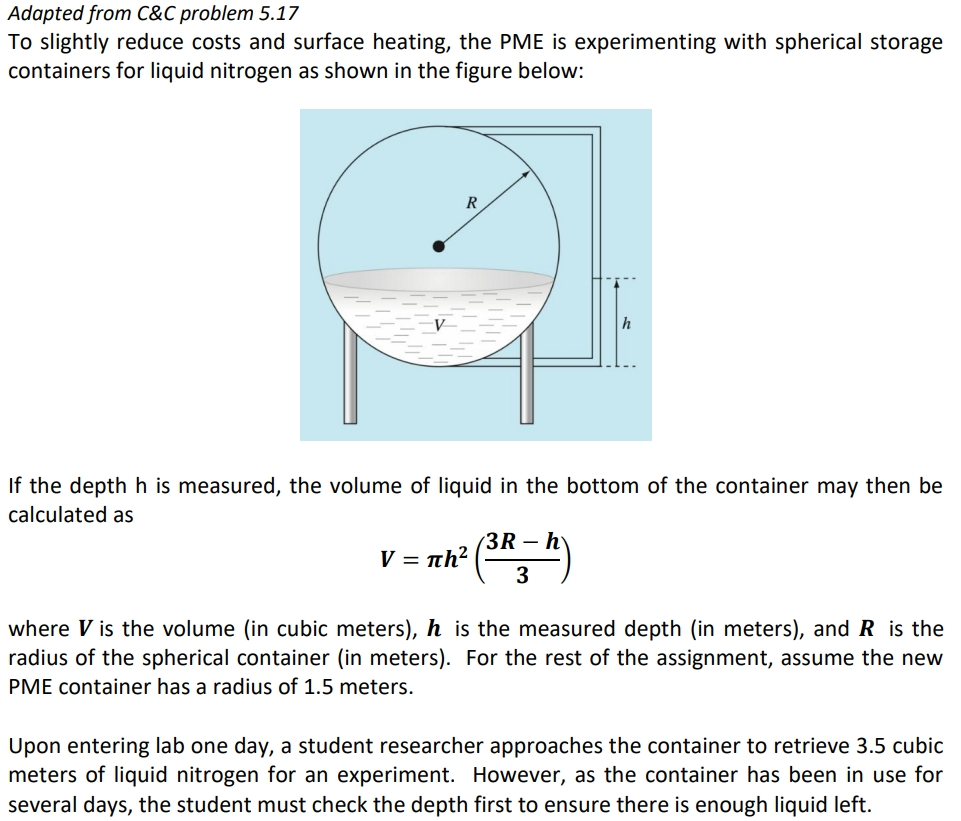

(a)	Write a function `V(h)` to compute the container volume as a function of depth.

In [3]:
def V(h):
    radius=1.5
    return (math.pi)*(h**2)*(((3*radius)-h)/3)
    

(b)	Write a function `depth_solve_bisect(V_fill, lower, upper, n)` to determine the depth of liquid in the container when it holds a volume of V_fill.  This function should use the bisect method with initial bounds $[lower, upper]$ and $n$ iterations.  What minimum depth of liquid do you calculate, using 15 iterations and initial bounds of $0$ and $R$, is required for the student to have sufficient liquid nitrogen?

In [4]:
def depth_solve_bisect(V_fill, lower, upper, n):
    guess = upper
    estimated_guess=[]
    for i in range(n):
        guess = (lower+upper)/2
        old_guess=guess
        estimated_guess.append(guess)
        if guess != 0:
            err = np.abs((guess-old_guess) / guess) * 100
        if V(guess) > V_fill:
            upper = guess
        else:
            lower = guess
    estimated_guess=np.array(estimated_guess)

    return guess, estimated_guess


In [5]:
R=1.5
V_fill=3.5
guess_bs, error_bs = depth_solve_bisect(V_fill,0,R,15)
print(f"The minimum depth of \
liquid required to have {V_fill} cubic meters of liquid\
 using the bisection method is\
{guess_bs:.5f} meters of nitrogen")

The minimum depth of liquid required to have 3.5 cubic meters of liquid using the bisection method is0.97353 meters of nitrogen


(c)	Write a function `depth_solve_fp(V_fill, lower, upper, n)` to determine the minimum depth such that there is sufficient liquid available.  This function should use the false-position method with initial bounds $[lower, upper]$ and $n$ iterations.  What minimum depth do you get using 15 iterations and initial bounds of $0$ and $R$?

In [6]:
def depth_solve_fp(V_fill, lower, upper, n):
    guess = upper 
    estimated_guess=[]
    for i in range(n):
        guess = upper - ((V(upper)-V_fill)*(lower-upper))\
            /((V(lower)-V_fill)-(V(upper)-V_fill))
        old_guess=guess
        estimated_guess.append(guess)
        if guess != 0:
            err = np.abs((guess-old_guess) / guess) * 100
        if (V(guess)-V_fill) > 0:
            upper = guess
        else:
            lower = guess
    estimated_guess=np.array(estimated_guess)


    return guess, estimated_guess


In [7]:


R=1.5
V_fill=3.5
guess_fp, error_fp = depth_solve_fp(V_fill,0,R,15)

print(f"The minimum depth of \
liquid required to have {V_fill} cubic meters of liquid\
 using the false-position method is \
{guess_fp:.10f} meters of nitrogen")


The minimum depth of liquid required to have 3.5 cubic meters of liquid using the false-position method is 0.9735307210 meters of nitrogen


(d)	Plot on the same axes the true percent relative error of both methods as a function of $n$ over the interval $[1, 15]$ to compare their rates of convergence.  Provide two plots as your solution using (i) linear and (ii) semilog-y (*i.e.*, x-axis is linear, y-axis is logarithmic base 10) scales for plotting.

In [8]:
#we need to calculate the true value. 
#The false position method is the best method. 
#We run 100 iterations and say that the output value is true value. 
iterations=100
guess_fp, error_fp = depth_solve_fp(V_fill,0,R,iterations)

print(f"True Value from False-Position Method: \
{guess_fp:.100} meters")

True Value from False-Position Method: 0.97353072097551696106876306657795794308185577392578125 meters


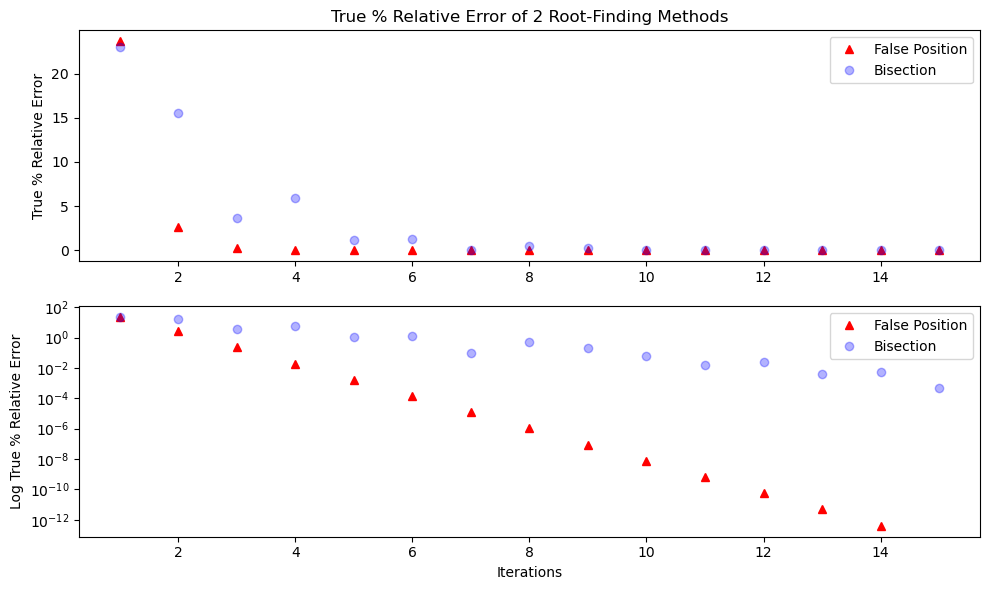

In [9]:
#this calculates the true rel error from estimated guess and true value
def error_maker(true_value, estimated_guess):
    true_rel_error = np.abs((estimated_guess - true_value)\
                             / true_value) * 100
    return true_rel_error

#derived from before
true_value = 0.97353072097551651697955321651534177362918853759765625

iterations=15
guess_fp, error_fp = depth_solve_fp(V_fill,0,R,iterations)
guess_bs, error_bs = depth_solve_bisect(V_fill,0,R,iterations)

X=np.linspace(1,15,15,endpoint=True)
error_bs_list = error_maker(true_value, error_bs)
error_fp_list = error_maker(true_value, error_fp)

plt.figure(figsize=(10,6))
plt.subplot(211)
plt.plot(X,error_fp_list,'r^', label = "False Position")
plt.plot(X,error_bs_list, 'ob',label = "Bisection", alpha=0.3)
plt.ylabel("True % Relative Error")
plt.title("True % Relative Error of 2 Root-Finding Methods")
plt.legend()
plt.tight_layout()

plt.subplot(212)
plt.semilogy(X,error_fp_list,'r^',label = "False Position", alpha=1)
plt.plot(X,error_bs_list, 'ob',label = "Bisection",alpha=0.3)
plt.legend()

plt.xlabel("Iterations")
plt.ylabel("Log True % Relative Error")
plt.tight_layout()
plt.show()


## Problem 2 - Open Methods for Root Finding and Convergence
<span style="color: red;">** **This problem will be covered in Discussion 2 on January 13** </span>

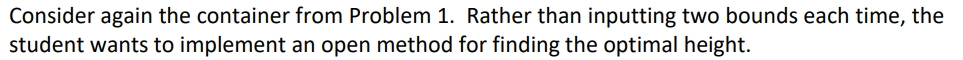

(a)	Write a function `V_prime(h)` to compute the derivative of the container volume as a function of depth.

In [10]:
def V_prime(h):
    R = 1.5
    return ((2 * np.pi * h * (R - (1/3)*h)) + np.pi * (h**2)*(-1/3))

#analytical derivative
def V_prime1(h):
    R=1.5
    return (2*np.pi*h*R - np.pi*(h**2))


(b) Write a function `depth_solve_nr(V_fill, guess, n)` to determine the depth of liquid in the container when it holds a volume of $V$_$fill$.  This function should use the Newton-Raphson method with an initial guess and $n$ iterations.  What value do you determine for 5 iterations and an initial guess of $R$?

In [11]:
def depth_solve_nr(V_fill,guess,n):
    #off-set function, since we want V=3.5
    def V_desired(guess_h, V_fill):
        return V(guess_h)-V_fill

    iteration = 0 
    guess_every_iter = []
    while iteration < n:
        guess_old = guess
        iteration += 1
        guess = guess_old - (V_desired(guess_old, V_fill)/ V_prime(guess_old))
        guess_every_iter.append(guess)

    return guess, guess_every_iter

depth_solve_nr(3.5,1.5,5)[0]



print(f"The Newton-Raphson Method predicts a depth of\
 {depth_solve_nr(3.5,1.5,5)[0]:.5f} meters of nitrogen \
when the container holds a volume of {V_fill} cubic meters.")

The Newton-Raphson Method predicts a depth of 0.97353 meters of nitrogen when the container holds a volume of 3.5 cubic meters.


(c)	Plot the true percent relative error for this method as a function of $n$ over the interval $[1, 5]$.  

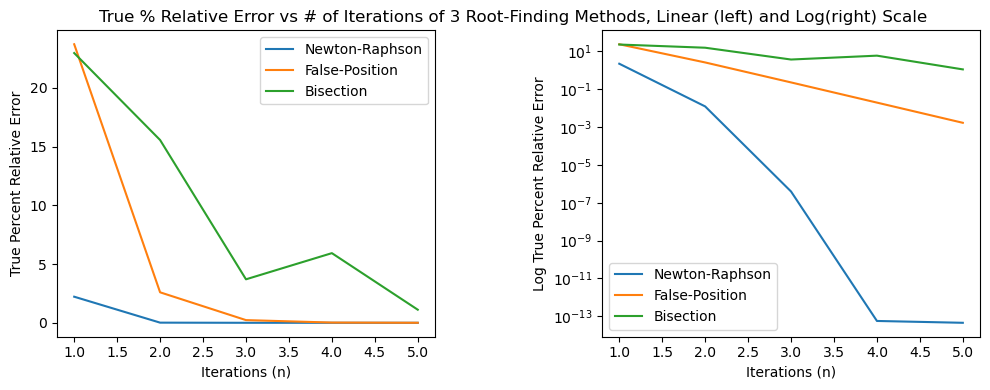

In [12]:

#true_value from before
true_zero = true_value
#calculation for true rel error
def true_rel_err(true_value, estimated_guess,n):
    for i in [1,5]: #iterates over the interval
        true_rel_error = np.abs((estimated_guess - true_value) \
/ true_value) * 100
    return true_rel_error

#calling the function for each depth_solve func
nr_tpre = np.abs(np.array(depth_solve_nr(3.5,1.5,5)[1])\
-true_zero)\
     / true_zero * 100

bs_tpre = np.abs(np.array(depth_solve_bisect(3.5,0,1.5,5)[1])\
-true_zero)\
 / true_zero * 100

fp_tpre = np.abs(np.array(depth_solve_fp(3.5,0,1.5,5)[1])\
-true_zero)\
      / true_zero * 100


fig, (ax1,ax2) = plt.subplots(figsize = (10,4), ncols= 2,nrows=1)
X = np.linspace(1,5,5)
ax1.plot(X,nr_tpre, label = "Newton-Raphson")
ax1.plot(X,fp_tpre, label = "False-Position")
ax1.plot(X,bs_tpre, label = "Bisection")
ax1.legend()
ax1.set_ylabel("True Percent Relative Error")
ax1.set_xlabel("Iterations (n)")
ax1.set_title("        True % Relative Error vs # of Iterations of\
 3 Root-Finding Methods, Linear (left) and Log(right) Scale",\
loc="left")

ax2.plot(X,nr_tpre, label = "Newton-Raphson")
ax2.plot(X,fp_tpre, label = "False-Position")
ax2.plot(X,bs_tpre, label = "Bisection")
ax2.set_ylabel("Log True Percent Relative Error")
ax2.set_yscale("log")
ax2.legend()
ax2.set_xlabel("Iterations (n)")
plt.tight_layout()
plt.show()




How does it compare to the previous bracketed methods?

Looking at the graphs, the Newton-Raphson method is signifigantly better than the previous bracketed methods. 
This is because it converges a lot faster as it uses the functions derivative, meaning it has quadratic convergence.
Compared to the linear convergence of bracketed methods, this causes root convergence to be much faster

(d) Another student needs liquid nitrogen and would like to use this method.  They need a larger volume of 10 cubic meters.  Since this volume is close to the full volume of the tank, the student uses an initial guess of $1.95R$ for the function.  What value is returned in this case after 5 iterations?

In [13]:
#take previously written function x(i+1) = XYZ...., 
# the depth_solve one, put in different V_fill of 10. 
#same function, just put in different numbers, 1.5*R
iter=5
R=1.5
vol=10
# print(depth_solve_nr(vol,1.95*R,iter)[1])
# print(depth_solve_nr(vol,1.95*R,iter)[0])

print(f"After {iter} iterations using the Newton Raphson Method,"
"the minimum depth to achieve a volume of {vol}"
f"cubic meters of liquid is \
{depth_solve_nr(10,1.95*R,iter)[0]:.5f} meters")

After 5 iterations using the Newton Raphson Method,the minimum depth to achieve a volume of {vol}cubic meters of liquid is -1.28486 meters


(e)	How would you modify the function to check for this kind of result?

The above function calculated a depth of -1.28 meters of liquid to achieve our desired volume, which is obviously wrong. 
This is because Newton Raphson method can diverge quickly if the ${initial}$ ${guess}$ is off. 
Some things to add to a function is error tolerance - we have a limit of iterations, but we could keep iterating over and over - 
-even if we're close to the answer. This just puts more strain on the computer

Other methods are checking and throwing errors if we get an undesired result.
In this case, we could raise an error if we find a root that's less than zero. 
Or, we can only iterate while our guess_root is greater than zero. 

Other things to stress test our function is to try a guess that's far from our expected root. In this case, we did 1.5 * R,
which triggered the error. 

## Problem 3 – 1D Fluid Transfer through a Lipid Bilayer

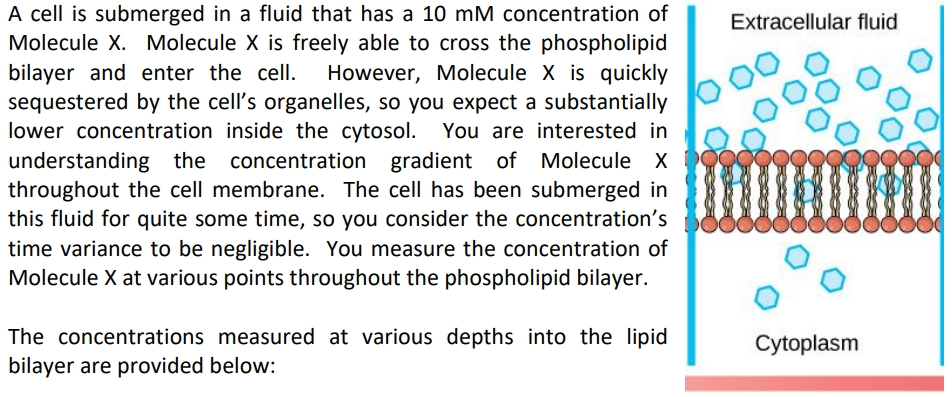

**Concentrations (mM):**

10. ,  9.98277344,  9.93109375,  9.84496094,  9.724375, 9.56933594,  9.37984375,  9.15589844,  8.8975,  8.60464844,  8.27734375,  7.91558594,  7.519375,  7.08871094,  6.62359375,  6.12402344,  5.59,  5.02152344,  4.41859375,  3.78121094,  3.109375,  2.40308594,  1.66234375,  0.88714844,  0.0775

**Depths (nm):**

0,  0.2625, 0.525 , 0.7875, 1.05 ,  1.3125 ,1.575 , 1.8375 ,2.1,    2.3625, 2.625 , 2.8875, 3.15, 3.4125, 3.675,  3.9375, 4.2, 4.4625, 4.725,  4.9875, 5.25, 5.5125, 5.775,  6.0375, 6.3


In [14]:
concentrations = [10. ,  9.98277344,  9.93109375,  9.84496094,  9.724375, 9.56933594,  9.37984375,  9.15589844,  8.8975,  8.60464844,  8.27734375,  7.91558594,  7.519375,  7.08871094,  6.62359375,  6.12402344,  5.59,  5.02152344,  4.41859375,  3.78121094,  3.109375,  2.40308594,  1.66234375,  0.88714844,  0.0775]
depths = [0,  0.2625, 0.525 , 0.7875, 1.05 ,  1.3125 ,1.575 , 1.8375 ,2.1,    2.3625, 2.625 , 2.8875, 3.15, 3.4125, 3.675,  3.9375, 4.2, 4.4625, 4.725,  4.9875, 5.25, 5.5125, 5.775,  6.0375, 6.3]

(a)	Given this data, estimate the first and second derivatives of the concentration with respect to depth using first-order finite differentiation. 

In [17]:
def first_deriv(depths,concentrations,step):
    slopes=[]
    n = len(concentrations)
    #because forward, we have to limit range
    for i in range(n-1):
        #slope formula for first order first deriv
        slope = (concentrations[i+1]-concentrations[i]) / (step)
        slopes.append(slope)
    return slopes

def second_deriv(depths,conc,step):
    slopes=[]
    n = len(conc)
    for i in range(n-2):
        slope = (conc[i+2] - 2 * conc[i+1] + conc[i]) / (step**2)
        slopes.append(slope)
        
        
    return(slopes)

# g= second_deriv(depths,concentrations,0.2625)
# print(first_deriv(depths,concentrations,0.2625))

# print(g)

print(f"The list of first order first derivative of Molecule X \
concentration with respect to depth is\
 {first_deriv(depths,concentrations,0.2625)} mM.")
print(f"The list of first order second derivative of Molecule X\
concentration with respect to depth is \
{second_deriv(depths,concentrations,0.2625)} mM.")

The list of first order first derivative of Molecule X concentration with respect to depth is [-0.06562499047618751, -0.19687500952381057, -0.32812499047619237, -0.45937500952380866, -0.5906249904761904, -0.7218750095238136, -0.8531249904761886, -0.9843750095238049, -1.1156249904761935, -1.2468750095238097, -1.3781249904761914, -1.5093750095238079, -1.6406249904761896, -1.7718750095238094, -1.903124990476191, -2.034375009523811, -2.1656249904761893, -2.296875009523809, -2.4281249904761926, -2.5593750095238086, -2.6906249904761905, -2.821875009523809, -2.9531249904761903, -3.0843750095238094] mM.
The list of first order second derivative of Molecule Xconcentration with respect to depth is [-0.5000000725623736, -0.499999927437645, -0.5000000725623478, -0.499999927437645, -0.5000000725623736, -0.49999992743761923, -0.5000000725623478, -0.49999992743767074, -0.5000000725623478, -0.499999927437645, -0.5000000725623478, -0.499999927437645, -0.5000000725623607, -0.499999927437645, -0.50000007

(b)	Next, estimate the first and second derivatives of the concentration with respect to depth using second-order finite differentiation.

In [15]:
def first_deriv_2nd_order(depths,conc,step):
    slopes=[]
    n = len(conc)
    for i in range(n-2):
        
        slope = (-conc[i+2]+4*conc[i+1] - 3*conc[i]) / ( 2* step)
        # we cant do this iteration at the last step becuase there's
        #  no n+1 value. 
        slopes.append(slope)
           # print(i)
    return slopes


def second_deriv_2nd_order(depths,conc,step):
    slopes=[]
    n = len(conc)
    for i in range(n-3):
        slope = (-conc[i+3] + 4 * conc[i+2] - 5 * conc[i+1]\
                  + 2*conc[i]) / (step**2)
        slopes.append(slope)
    return(slopes)




print(f"The list of second order first\
 derivative of Molecule X concentration\
 with respect to depth is \
{first_deriv_2nd_order(depths,concentrations,0.2625)} mM.")
print(f"The list of second order second \
derivative of Molecule X\
 concentration with respect to depth is \
{second_deriv_2nd_order(depths,concentrations,0.2625)} mM.")

The list of second order first derivative of Molecule X concentration with respect to depth is [1.9047620623626112e-08, -0.1312500190476163, -0.26249998095238425, -0.39375001904762114, -0.5249999809523755, -0.656250019047626, -0.7874999809523804, -0.9187500190476038, -1.0499999809523852, -1.1812500190476223, -1.3124999809523834, -1.4437500190476136, -1.5749999809523816, -1.7062500190476184, -1.8374999809523795, -1.9687500190476164, -2.0999999809523775, -2.231250019047618, -2.362499980952386, -2.4937500190476194, -2.6249999809523805, -2.7562500190476174, -2.887499980952381] mM.
The list of second order second derivative of Molecule X concentration with respect to depth is [-0.5000002176871279, -0.49999978231299375, -0.5000002176870764, -0.4999997823129422, -0.5000002176871794, -0.49999978231289066, -0.5000002176870247, -0.49999978231299375, -0.5000002176870247, -0.4999997823129422, -0.5000002176870247, -0.49999978231289066, -0.5000002176870247, -0.4999997823129422, -0.5000002176871021, 

(c)	At this point, you should have 4 new arrays: 2 for the first spatial derivative of concentration and 2 for the second spatial derivative of concentration.  Generate a single scatter plot of these 4 arrays, as well as the original measured concentration array, versus the measured depth array.  Include a legend and label each axes, and make sure that each dataset is represented by a distinct color.

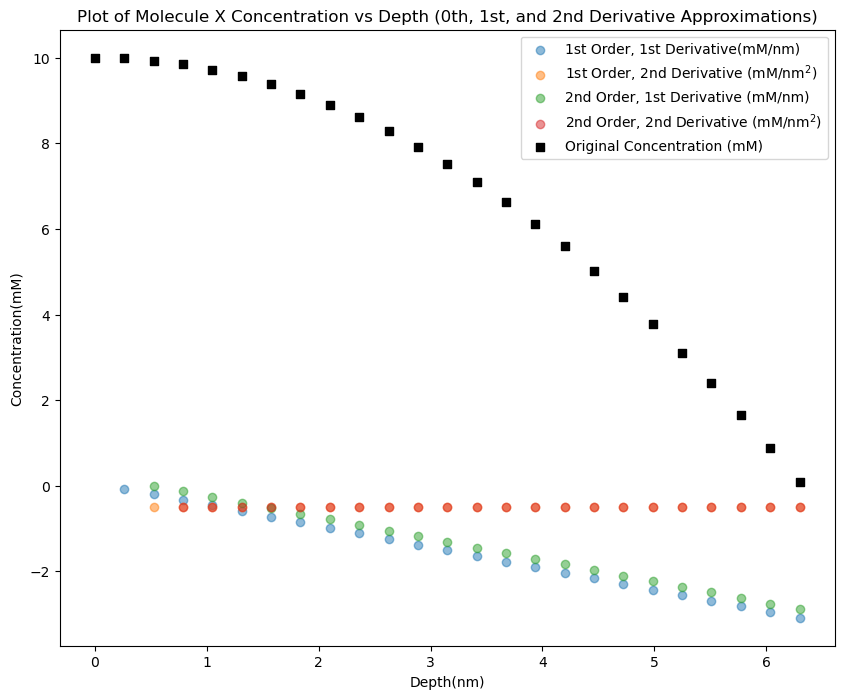

In [16]:
#order_derivative
first_first = first_deriv(depths,concentrations,0.2625)
first_second = second_deriv(depths,concentrations,0.2625)

second_first = first_deriv_2nd_order(depths,concentrations,0.2625)
second_second = second_deriv_2nd_order(depths,concentrations,0.2625)


fig, ax = plt.subplots(1,1)
fig.set_size_inches(10,8)
#scatter plot, plotting all the derivatives
ax.scatter(depths[1:],first_first, label = "1st Order, \
1st Derivative\
(mM/nm)",alpha=0.5)
ax.scatter(depths[2:],first_second, label = "1st Order, \
2nd Derivative (mM/nm$^{2}$)",alpha=0.5)
ax.scatter(depths[2:],second_first, label = "2nd Order, \
1st Derivative (mM/nm)", alpha=0.5)
ax.scatter(depths[3:],second_second,label = "2nd Order, \
2nd Derivative (mM/nm$^{2}$)",alpha=0.5)

ax.set_title("Plot of Molecule X Concentration vs Depth \
(0th, 1st, and 2nd Derivative Approximations)")
#original function
ax.scatter(depths,concentrations,label = "Original \
Concentration (mM)",c="black",marker="s")
ax.legend()
ax.set_ylabel("Concentration(mM)")
ax.set_xlabel("Depth(nm)")
plt.show()


(d) You determine that the concentration of Molecule X in the phospholipid bilayer follows the equation $C(x)=ax^2+b$ in terms of constants $a$ and $b$, where $x$ represents the depth in nm, and $C$ is given in mM.  Create a function which returns the concentration given 3 arguments ($a$, $b$, and $x$).  Create functions which return the first and second spatial derivatives of the concentration as well.

In [17]:
#function for true concentration 
def conc(a,b,depth):
    conc = []
    for i in range(len(depth)):
        current_conc = a*(depth[i]**2) + b
        conc.append(current_conc)
    return conc
#function for true spatial analytical 1st derivative
def true_first_deriv(depths,conc,a,b):
    slopes=[]
    n = len(depths)
    for i in range(n):
        slope = 2*a*depths[i]

        slopes.append(slope)
    
    return(slopes)

#function for true spatial analytical 2nd derivative
def true_second_deriv(depths,conc,a,b):
    slopes=[]
    n = len(depths)
    for i in range(n):
        slope = 2*a
        slopes.append(slope)
    
    return(slopes)

a = -1/4
b= 10
step = 0.2625

#theoretical concentration using formula
theory_conc = conc(a,b,depths)

#error checking
    # print(len(true_second_deriv(depths,theory_conc,a,b)))
    # print(len(true_first_deriv(depths,theory_conc,a,b)))
    # print(len(depths))

    # print(len(first_first))
    # print(len(first_second))

(e) You find that constant values $a=-1/4$ mM/nm$^2$  and $b=10$ mM ideally model the concentration gradient for Molecule X in the phospholipid bilayer.  Using the functions created in part (d), plot the ideal model for the first and second derivatives of concentration versus depth as continuous curves.  Then, overlay a scatter plot of your numerical estimates for the first and second derivatives from the measured data.

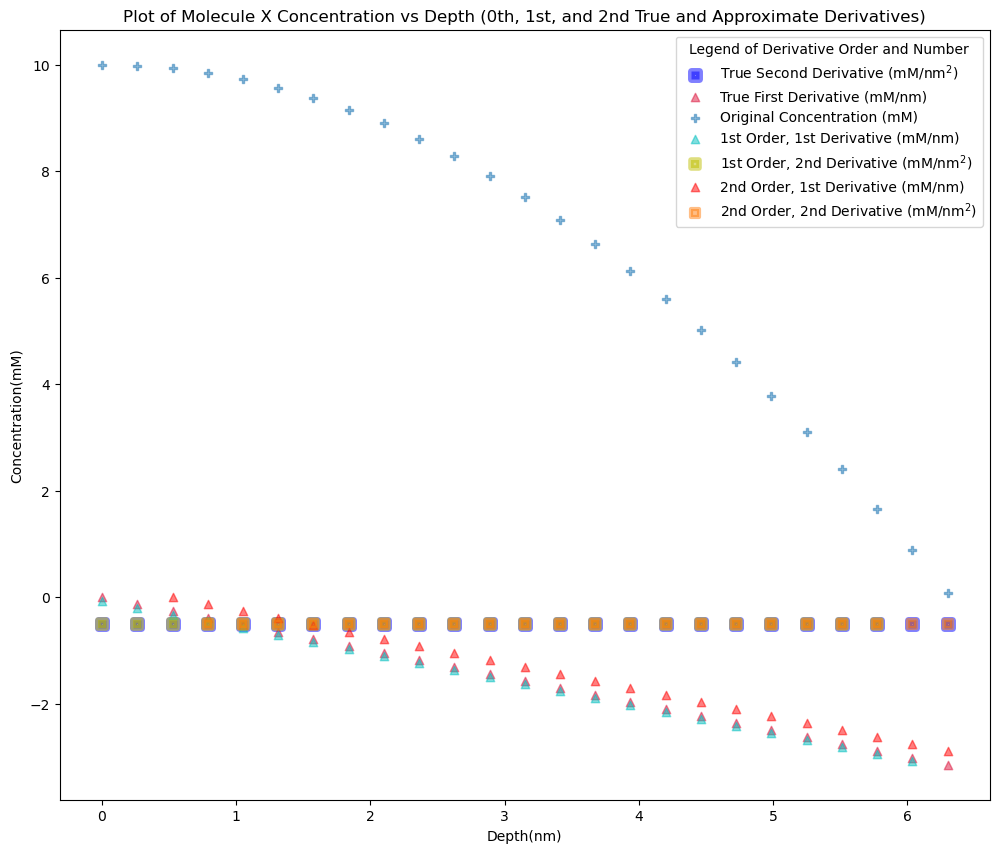

In [18]:
a = -1/4
b= 10
step = 0.2625

#error checking
    # theory_conc = conc(a,b,depths)
    # print(theory_conc)
    # print(depths)
    # print(len(theory_conc))

    # print(len(depths))

    # print(len(true_second_deriv(depths,theory_conc,a,b)))
    # print(len(true_first_deriv(depths,theory_conc,a,b)))
    # print("HELLO",true_second_deriv(depths,theory_conc,a,b))
    # print(true_first_deriv(depths,theory_conc,a,b))



plt.figure(figsize=(12,10))
#calling functions of true second derivatives
plt.scatter(depths,true_second_deriv(depths,theory_conc,a,b),\
marker="s",c="b",label = "True Second Derivative (mM/nm$^{2}$)",\
alpha=0.5,linewidths=5)
plt.scatter(depths,true_first_deriv(depths,theory_conc,a,b),\
c="crimson",label = "True First Derivative (mM/nm)",\
marker="^",alpha=0.5)
plt.scatter(depths,concentrations,\
label = "Original Concentration (mM)",marker="P",alpha=0.5)


#old plots
plt.scatter(depths[:-1],first_first, \
label = "1st Order, 1st Derivative (mM/nm)",c="c",marker="^",\
alpha=0.5)
plt.scatter(depths[:-2],first_second, \
label = "1st Order, 2nd Derivative (mM/nm$^{2}$)",c="y",\
marker="s",linewidths=4,alpha=0.5)
plt.scatter(depths[2:],second_first, \
label = "2nd Order, 1st Derivative (mM/nm)",c="red",\
marker = "^",alpha=0.5)
plt.scatter(depths[3:],second_second,\
label = "2nd Order, 2nd Derivative (mM/nm$^{2}$)",\
marker="s",linewidths=3,alpha=0.5)
plt.ylabel("Concentration(mM)")
plt.xlabel("Depth(nm)")
plt.legend(title="Legend of Derivative Order and Number")
plt.title("Plot of Molecule X Concentration vs Depth \
(0th, 1st, and 2nd True and Approximate Derivatives)")
plt.show()


(f)	Define the “true value” to be the theoretical first and second derivatives predicted from the model equation provided in part (d).  Define the “estimate” to be the first and second derivatives of the measured data calculated using first-order finite differentiation in part (a).  Calculate the true fractional relative error of the estimates for the first and second derivatives accordingly.  Sum the true relative errors at all recorded depths for which you have estimated derivatives, and print the results to 4 significant figures.

In [19]:
a = -1/4
b= 10
step = 0.2625

#aquriing the true and approximate values
true_1st = true_first_deriv(depths,theory_conc, a,b)
true_2nd = true_second_deriv(depths,theory_conc,a,b)

appx_1st = first_deriv(depths,concentrations,step)
appx_2nd = second_deriv(depths,concentrations,step)

# print(len(true_1st))#25
# print(len(true_2nd))#25
# print(len(appx_1st))#24
# print(len(appx_2nd))#23

#sum function
def sum(yay):
    sum = 0
    for i in range(len(yay)):
        sum += yay[i]
    return sum

#true fractional relative error function
def tfre(true,appx):
    errors = []
    for i in range(1,len(true)):
        err = abs((true[i] - appx[i]) / true[i]) 
        #print(err)
        errors.append(err)
    return errors
    
one_derivs = tfre(true_1st[:-1],appx_1st)
two_derivs = tfre(true_2nd[:-2],appx_2nd)

print(f"The true fractional relative error of the first derivative \
estimates are {sum(two_derivs):.4g}")
print(f"The true fractional relative error of the second \
derivative estimates are {sum(one_derivs):.4g}")


The true fractional relative error of the first derivative estimates are 3.193e-06
The true fractional relative error of the second derivative estimates are 1.867


## Problem 4  –  Crank Around and Find Out!

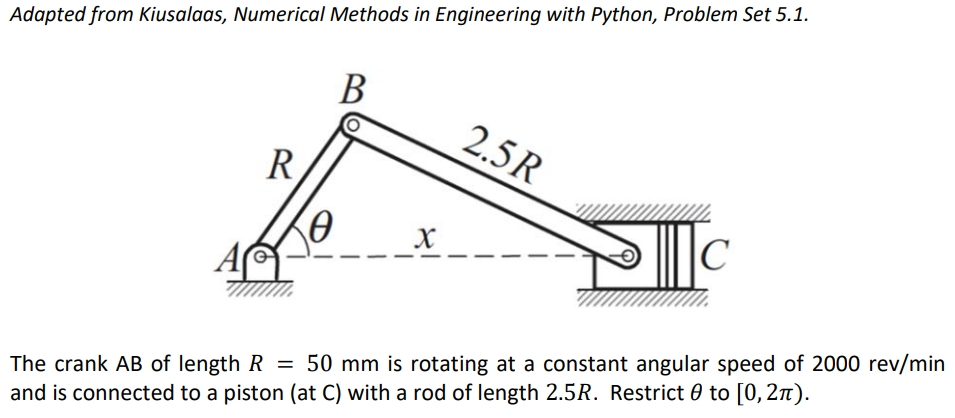

(a) Derive an expression for the position of the piston $x(θ)$ (in mm) as a function of angle $θ$.  *(Hint:  Write $x$ as a sum of contributions from crank AB and BC using geometry.)*

x = $\sqrt{(2.5R)^2 - ({Rsin(\theta)})^2} + Rcos(\theta)$

Derivation is shown in attached PDF

(b) Use a root-finding method of your choice to compute the crank angles where $x(θ)$ is maximized and minimized.  Compute the corresponding $x_{max}$ and $x_{min}$ (in mm). Compare the results to your geometric intuition.

In [20]:
#this makes an array of our theta range
theta_range = np.linspace(0,2*np.pi,100, endpoint=False)

#defines x position based on theta from our expression
def x_pos(theta):
    R=50
    x_pos = np.sqrt(((2.5*R)**2)-((R*np.sin(theta))**2)) + \
R*np.cos(theta)
    return x_pos

#analytical first position derivative
def deriv_pos(theta):
    R=50
    return (((-R**2)*(np.sin(theta))*(np.cos(theta)) / \
np.sqrt(((2.5*R)**2-((R*np.sin(theta))**2))))- R*np.sin(theta))

#function that finds multiple roots of a given range (theta_range)
def roots_bisect_multipleroots(f, theta_range, n):
    roots = []
    n = len(theta_range)
    #searches through range
    for i in range(n-1):
        #assings current and next values
        theta = theta_range[i]
        theta_next = theta_range[i+1]
        
        #if a possible root is found... 
        if f(theta)*f(theta_next) < 0 :
            #then call root finding function
            root = zero_solve_fp(f,theta,theta_next,n)
            #and append that root to list of roots
            roots.append(root)
        elif f(theta)==0:
            #for the case where theta=0
            roots.append(theta)
    return roots

#root solver function, for false position
def zero_solve_fp(f, lower, upper, n):
    guess = upper 
    estimated_guess=[]

    #f is the function: deriv_pos
    for i in range(n):
        guess = upper - f(upper) * (lower - upper) / \
(f(lower) - f(upper))
        #old_guess = guess
        if f(lower) * f(guess):
            upper = guess
        else: 
            lower = guess

    return guess

#calls the function and assigns the two roots to "list_of_roots"
list_of_roots = roots_bisect_multipleroots(deriv_pos,theta_range, 25)

#function for the min and max x_pos values
#however, this only works for two roots
def min_max(f, roots):
    n = len(roots)
    for i in range(n-1):
        theta=roots[i]
        theta2=roots[i+1]
        if x_pos(theta) > x_pos(theta2):
            print(f"The theta value {theta:.5f} rad produces the max \
piston position of {x_pos(theta):.2f}mm, \
and theta value {theta2:.5f} rad produces the min piston position \
of {x_pos(theta2):.2f}mm")
        elif x_pos(theta) < x_pos(theta2):
            print(f"The theta value {theta:.3f} rad produces the \
min piston position of {x_pos(theta):.3f}mm, \
and theta value {theta2:.3f} rad produces the max piston \
position of {x_pos(theta2):.2f}mm")

#calls min/max function
min_max(x_pos,list_of_roots)



The theta value 0.00000 rad produces the max piston position of 175.00mm, and theta value 3.14159 rad produces the min piston position of 75.00mm


(c) Derive an analytical expression $a_A(t)$ for the acceleration of the piston as a function of time $t$ (in seconds).

#look at PDF

(d) Use the centered second-order finite-difference approximation to the second derivative to numerically compute the acceleration $a_{FD}(t)$ as a function of $t$ (in seconds), using a step size of $Δθ = 5°$. *(Hint: Convert this to $Δt$.)*  Plot $a_A(t)$ and $a_{FD}(t)$ in the same graph over one revolution. *(Hint: You may choose to not worry about the end points and for simplicity only focus on the interior grid.)*

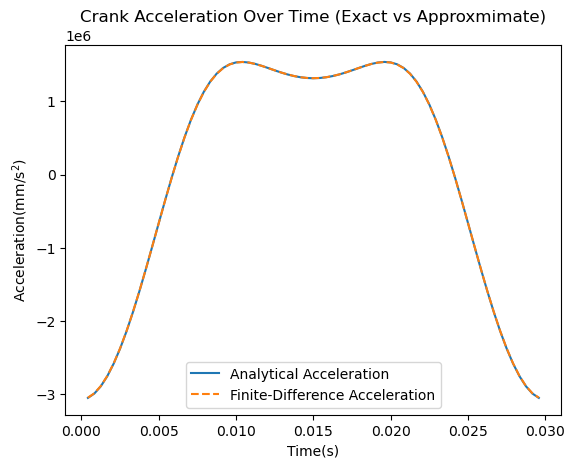

In [21]:

#analytical acceleration derivative of position
def accel(theta):
    return ((-2500*((np.sqrt(15625-2500*((np.sin(theta))**2)))*\
(((np.cos(theta))**2)-((np.sin(theta))**2))+\
(2500*((np.cos(theta))**2)*((np.sin(theta))**2))/\
((np.sqrt(15625-2500*((np.sin(theta))**2))))) / (15625-2500*\
((np.sin(theta))**2))) - 50*np.cos(theta))

#converting acceleration with resepect to theta
#to respect to time
def a_accel(time):
    theta = spin * time
    return (spin**2) * accel(theta)

#converts position with respecet to theta
#to respect to time
def x_pos(time):
    theta = spin * time
    return np.sqrt(15625 - 2500*np.sin(theta)**2) + 50*np.cos(theta)

#we need to change the step size
#which in turn changes the step and range that we're iterating over
#this function adjusts the step based on step size
#which is helpful for part E
def dt_maker(step_size):
    #converts degrees to rad 
    step = step_size * np.pi / 180
    
    #converts rad to sec
    dt = step / spin
    
    #converts rad to sec
    limit = (2*np.pi / spin)

    #"theta" or "time" iteration range
    time_range = np.arange(0, limit + dt, dt)
    return time_range, dt

#angular speed of crank
spin = (2000*2*np.pi) / 60

#assigns time range and iteration step for 5 degrees
t5, dt5 = dt_maker(5)

#finite-difference center derivative appx
def fin_diff(f, time_range, dt):
    accel = []
    for i in range(1, len(time_range)-1):
        acc = (f(time_range[i+1]) - 2*f(time_range[i]) + \
f(time_range[i-1])) / dt**2
        accel.append(acc)
    return accel

#calculates the appx and real accelerations
acc_fin_diff = fin_diff(x_pos,t5,dt5)
acc_a = a_accel(t5[1:-1])


#plotting
plt.plot(t5[1:-1], acc_a, label="Analytical Acceleration")
plt.plot(t5[1:-1], acc_fin_diff, "--", \
label="Finite-Difference Acceleration")
plt.xlabel("Time(s)")
plt.ylabel("Acceleration(mm/s${^2}$)")
plt.legend()
plt.title("Crank Acceleration Over Time \
(Exact vs Approxmimate)")

plt.show()


(e)	Repeat (d) using $Δθ = 40°$, $20°$, $10°$, and $5°$.  Plot $a_A(t)$ and $a_{FD}(t)$ with these different $Δθ$ in the same graph over one revolution.  For each $Δθ$, compute the average true error over the interior time grid ($E_{avg}(Δθ)=\frac{1}{N} \sum_{i=1}^{N} |a_{FD}(t)-a_A(t)|)$.  Plot $E_{avg}(Δθ)$ versus $Δθ$ on a log-log plot and estimate the slope (linear regression is optional).  How does the slope compare to the expected $O(Δθ^2)$ behavior for the centered second-order finite-difference method?

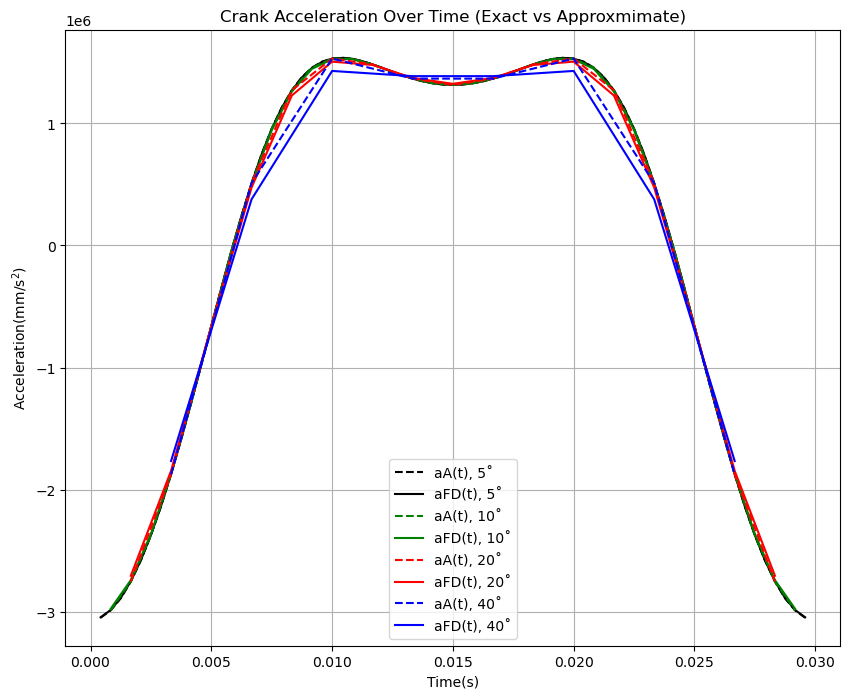

In [22]:

#repasting the step/range maker
def dt_maker(step_size):
    step = step_size * np.pi / 180
    dt = step / spin
    limit = (2*np.pi / spin)
    time_range = np.arange(0, limit + dt, dt)
    return time_range, dt

#changing the step/range for each ∆theta
t5, dt5 = dt_maker(5)
t10,dt10 = dt_maker(10)
t20,dt20 = dt_maker(20)
t40,dt40=dt_maker(40)

#calling appx and real acc function with 
#the respective range and step
acc_fin_diff_5 = fin_diff(x_pos,t5,dt5)
acc_a_5 = a_accel(t5[1:-1])

acc_fin_diff_10 = fin_diff(x_pos,t10,dt10)
acc_a_10 = a_accel(t10[1:-1])

acc_fin_diff_20 = fin_diff(x_pos,t20,dt20)
acc_a_20 = a_accel(t20[1:-1])

acc_fin_diff_40 = fin_diff(x_pos,t40,dt40)
acc_a_40 = a_accel(t40[1:-1])


#plotting!
plt.figure(figsize=(10,8))

plt.plot(t5[1:-1],acc_a_5, "--",c="black",label = "aA(t), 5˚")
plt.plot(t5[1:-1],acc_fin_diff_5,c="black", label = "aFD(t), 5˚")

plt.plot(t10[1:-1],acc_a_10,"--", c="g", label = "aA(t), 10˚")
plt.plot(t10[1:-1],acc_fin_diff_10,c="g",label = "aFD(t), 10˚")

plt.plot(t20[1:-1],acc_a_20,"--",c="r", label = "aA(t), 20˚")
plt.plot(t20[1:-1],acc_fin_diff_20,c="r", label = "aFD(t), 20˚")

plt.plot(t40[1:-1],acc_a_40,"--",c="b", label = "aA(t), 40˚")
plt.plot(t40[1:-1],acc_fin_diff_40,c="b", label = "aFD(t), 40˚")
plt.legend(loc = "lower center")


plt.xlabel("Time(s)")
plt.ylabel("Acceleration(mm/s${^2}$)")

plt.title("Crank Acceleration Over Time (Exact vs Approxmimate)")
plt.grid()
plt.show()


(f) Use Richardson’s extrapolation to improve the centered finite-difference estimate.  Use the step sizes $Δθ = 5°$ and $Δθ/2 =  2.5°$.
* Use Richardson extrapolation to derive the formula for an improved estimate $a_R(t)$ in terms of $a_{Δθ}(t)$ and $a_{Δθ/2}(t)$.


See PDF

* Compute the average true errors of the estimates $a_{Δθ}(t)$, $a_{Δθ/2}(t)$, and $a_R(t)$.  

In [23]:
#richard extrapolation formula
def re_a(one,half):
    #"one" is full step
    #"half" is half step
    a = (4/3)*(half) - (1/3)*(one)
    return a

#function for average true error
def avg_te(real,appx):
    error = np.abs(appx - real)
    return np.mean(error)

#sets up the steps again for ∆theta = 5, 2.5
t5, dt5 = dt_maker(5)
t2dot5,dt2dot5 = dt_maker(2.5)

#runs the acceleration functions
acc_fin_diff_5 = np.array(fin_diff(x_pos,t5,dt5))
acc_a_5 = a_accel(t5[1:-1])

acc_fin_diff_2dot5 = np.array(fin_diff(x_pos,t2dot5,dt2dot5))
acc_a_2dot5 = a_accel(t2dot5[1:-1])

#calculates richardson acceleration
rich_acc = np.array(re_a(acc_fin_diff_5[:],acc_fin_diff_2dot5[1::2]))
#[::2] means the step size is 2. 

#all three true errors
avg_true_error_rich =avg_te(acc_a_5,rich_acc)
avg_true_error_full = avg_te(acc_a_5 ,acc_fin_diff_5)
avg_true_error_half = avg_te(acc_a_2dot5 ,acc_fin_diff_2dot5)

print(f"The average true error of the full 5˚ step acceleration\
 using the finite-difference method is {avg_true_error_full:.5f}.")
print(f"The average true error of the full 2.5˚ step acceleration \
using the finite_difference method is {avg_true_error_half:.5f}.")
print(f"The average true error of the full 5˚ step acceleration \
using Richardson's extrapolation is {avg_true_error_rich:.5f}.")


#Bug fixing length stuff
    # print(len(acc_fin_diff_2dot5))
    # len(acc_fin_diff_5)

    # print(acc_fin_diff_5)
    # print(acc_fin_diff_2dot5[1::2])

    # print(len((acc_fin_diff_2dot5)[1::2]))
    # len(acc_fin_diff_5)


The average true error of the full 5˚ step acceleration using the finite-difference method is 1585.16820.
The average true error of the full 2.5˚ step acceleration using the finite_difference method is 399.30981.
The average true error of the full 5˚ step acceleration using Richardson's extrapolation is 0.43734.


* Comment on the difference.

The differences make somewhat sense. Using the center finite difference formulas provides an error of O(h^2) (~1600). This means that if we divide the step size by two, then the subsequent error should reduce by a factor of 2^2. It is the power of two because it is the second order squared. This is observed, as the halved step size has a average true error of ~400, which is 1/4 of the original full step error. 

In terms of the richardson's extrapolation error, it is signifigantly smaller, and this makes sense because it has a fourth order error term, meaning it is much more accurate. Error gets reduces (to the power of two) times faster than the previous method.